In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

In [3]:
file_path = '/content/drive/MyDrive/deep_learning_denoising'
os.listdir(file_path)

['renderings']

In [4]:
!pip install openexr numpy matplotlib


In [5]:
import OpenEXR
import Imath
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

def read_exr(path):
    exr = OpenEXR.InputFile(path)
    dw = exr.header()['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    r = np.frombuffer(exr.channel('R', FLOAT), dtype=np.float32)
    g = np.frombuffer(exr.channel('G', FLOAT), dtype=np.float32)
    b = np.frombuffer(exr.channel('B', FLOAT), dtype=np.float32)

    r = r.reshape(height, width)
    g = g.reshape(height, width)
    b = b.reshape(height, width)

    img = np.stack([r, g, b], axis=-1)
    return img

In [6]:
noisy_path = "/content/drive/MyDrive/deep_learning_denoising/renderings/room3/18409078-00128spp.exr"
clean_path = "/content/drive/MyDrive/deep_learning_denoising/renderings/room3/18409078-08192spp.exr"

noisy_np = read_exr(noisy_path)
clean_np = read_exr(clean_path)

print(noisy_np.shape)

(720, 1280, 3)


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

noisy = torch.from_numpy(noisy_np).permute(2,0,1).unsqueeze(0).to(device)
clean = torch.from_numpy(clean_np).permute(2,0,1).unsqueeze(0).to(device)

print(noisy.shape)

torch.Size([1, 3, 720, 1280])


In [8]:
from kpcn_model import KPCN

model = KPCN().to(device)
model.eval()

with torch.no_grad():
    output = model(noisy)

print(output.shape)

torch.Size([1, 3, 720, 1280])


In [9]:
loss = torch.nn.functional.l1_loss(output, clean)
print("L1 Loss:", loss.item())

L1 Loss: 0.11694355309009552


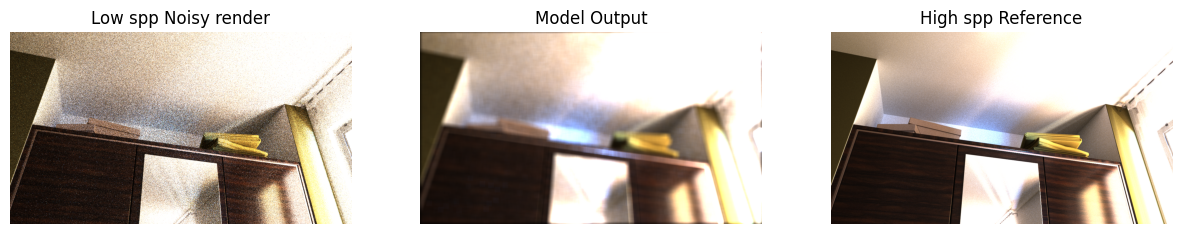

In [10]:
out_np = output.squeeze(0).permute(1,2,0).cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Low spp Noisy render")
plt.imshow(np.clip(noisy_np,0,1))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Model Output")
plt.imshow(np.clip(out_np,0,1))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("High spp Reference")
plt.imshow(np.clip(clean_np,0,1))
plt.axis("off")

plt.show()

In [ ]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# for i in range(100):
#     optimizer.zero_grad()
#     output = model(noisy)
#     loss = torch.nn.functional.l1_loss(output, clean)
#     loss.backward()
#     optimizer.step()

#     if i % 20 == 0:
#         print(i, loss.item())